# Artificial Neural Network / MLP (PyTorch)

An ANN (Multi-Layer Perceptron) stacks several layers of perceptron-like units with
non-linear activations in between, letting it learn non-linear decision boundaries
that a single perceptron cannot.

We classify handwritten digits (0-9) from the **`sklearn` digits dataset**
(`load_digits`, 1797 real 8x8 grayscale images), using a small feedforward network
with two hidden layers.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(0)

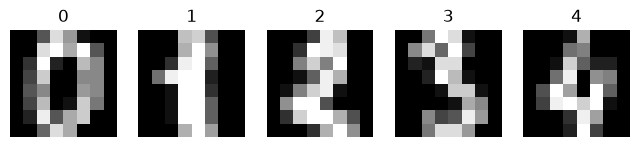

In [2]:
digits = load_digits()
X, y = digits.data, digits.target  # X: (1797, 64) flattened 8x8 images, y: digit 0-9

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

fig, axes = plt.subplots(1, 5, figsize=(8, 2))
for ax, img, label in zip(axes, digits.images[:5], digits.target[:5]):
    ax.imshow(img, cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.show()

In [3]:
class ANN(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        return self.net(x)


model = ANN(n_features=64, n_classes=10)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [4]:
losses = []
for epoch in range(60):
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  loss {loss.item():.4f}")

epoch  10  loss 0.5503
epoch  20  loss 0.0913
epoch  30  loss 0.0233
epoch  40  loss 0.0058
epoch  50  loss 0.0022
epoch  60  loss 0.0011


Test accuracy: 0.964


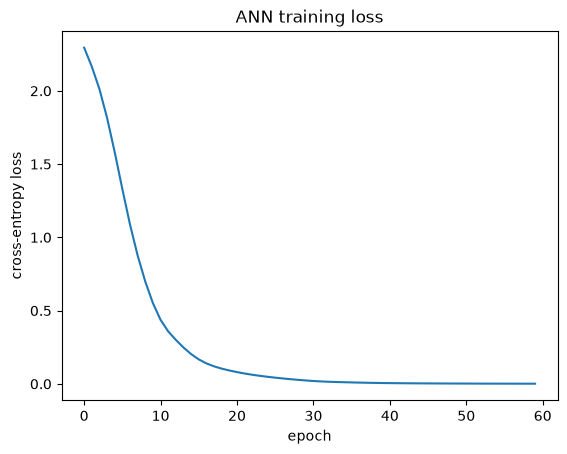

In [5]:
with torch.no_grad():
    preds = model(X_test).argmax(dim=1)
    accuracy = (preds == y_test).float().mean().item()

print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("ANN training loss")
plt.show()